<a href="https://colab.research.google.com/github/cadenlin21/bitcoin_day_trader/blob/main/trader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
#TO DO 
# figure out what to do with gold price

# make simple, super confident model - make sure it makes at least *some* money
# look at SMA and gardient over longer periods of times
#instead of gradient at one point, look at sma of gradient?
#do kaggle time series tutorial

#### Data preparation

In [47]:
import pandas as pd
import numpy as np

#Loading data
bitcoin_file = "/content/drive/MyDrive/CUMMW/2022_Problem_C_DATA/BCHAIN-MKPRU.csv"
gold_file = "/content/drive/MyDrive/CUMMW/2022_Problem_C_DATA/LBMA-GOLD.csv"
bitcoin_df = pd.read_csv(bitcoin_file)
gold_df = pd.read_csv(gold_file)
bitcoin_df.set_index('Date', inplace=True)
gold_df.set_index('Date', inplace=True)

<Axes: xlabel='Date'>

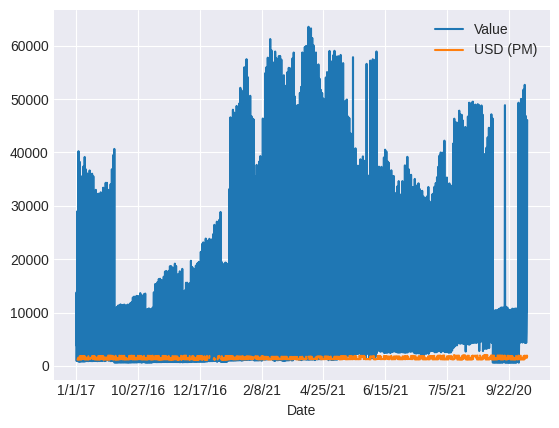

In [48]:
# merging gold and bitcoin data
result = bitcoin_df.join(gold_df, how='outer')
result.plot()

In [49]:
# adding old index back so "Date" becomes a column once again
result = result.reset_index()
#converting date to datetime format to sort
result['Date'] = pd.to_datetime(result['Date'])
# sorting entries by date
result.sort_values(by='Date', inplace = True)
result = result.reset_index()
result = result.drop('index',axis=1)
#renaming columns
result = result.rename(columns={"Value": "bitcoin-price", "USD (PM)": "gold-price"})
# column t - days since 2016-9-11
result["t"] = (result["Date"]-result["Date"][0]).dt.days
result

,Date,bitcoin-price,gold-price,t
0,2016-09-11,621.65,NaN,0
1,2016-09-12,609.67,1324.60,1
2,2016-09-13,610.92,1323.65,2
3,2016-09-14,608.82,1321.75,3
4,2016-09-15,610.38,1310.80,4
...,...,...,...,...
1821,2021-09-06,51769.06,1821.60,1821
1822,2021-09-07,52677.40,1802.15,1822
1823,2021-09-08,46809.17,1786.00,1823
1824,2021-09-09,46078.38,1788.25,1824


In [50]:
#Handing missing gold
print(result.isnull().sum())
# filling gold price with the price AFTER since its easier for now
result = result.fillna(method='bfill', axis=0)
print(result.isnull().sum())

Date               0
bitcoin-price      0
gold-price       571
t                  0
dtype: int64
Date             0
bitcoin-price    0
gold-price       0
t                0
dtype: int64


#### Initial plots

In [51]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

<Axes: title={'center': 'Bitcoin price over time'}>

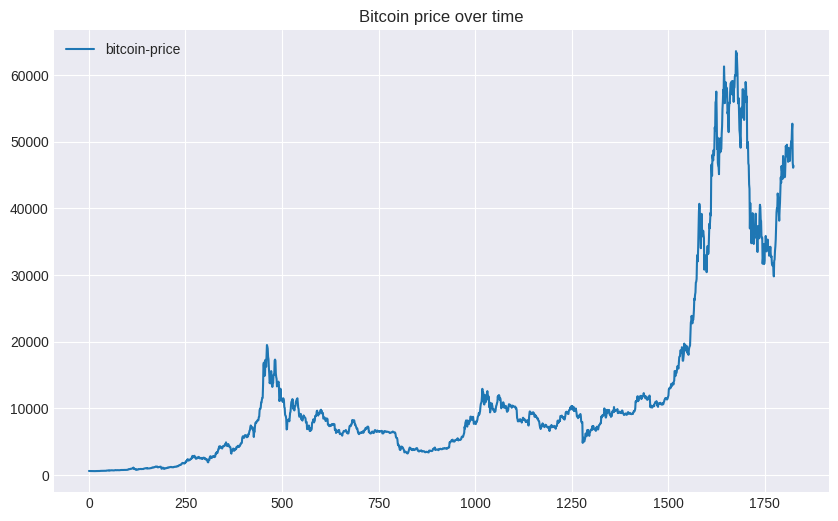

In [52]:
# Set the width and height of the figure
plt.figure(figsize=(10,6))
# Add title
plt.title("Bitcoin price over time")
sns.lineplot(data=result[['bitcoin-price']])

<Axes: title={'center': 'Gold price over time'}>

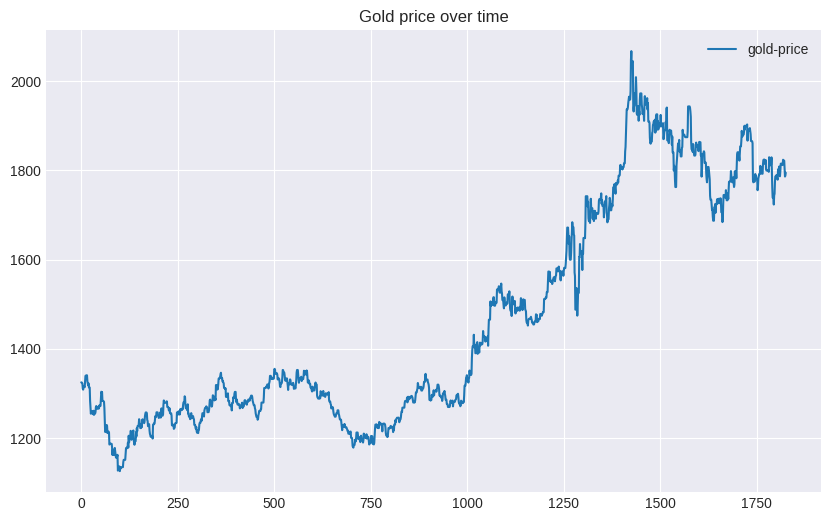

In [53]:
# Set the width and height of the figure
plt.figure(figsize=(10,6))
# Add title
plt.title("Gold price over time")
sns.lineplot(data=result[['gold-price']])

<Axes: title={'center': 'Gold and bitcoin'}>

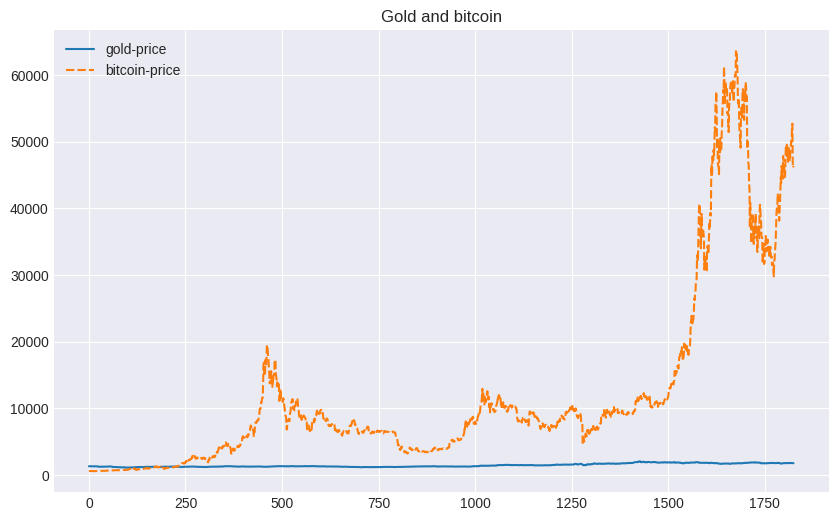

In [54]:
# Set the width and height of the figure
plt.figure(figsize=(10,6))
# Add title
plt.title("Gold and bitcoin")
sns.lineplot(data=result[['gold-price', 'bitcoin-price']])

#### Model

In [55]:
def buy(asset, curr_price, buy_value, assets, cash, comission):
  if buy_value <= cash:
    cash = cash - buy_value
    buy_amount = buy_value/curr_price
    assets[asset] += (1-comission)*buy_amount
    #print(f"bought {buy_amount} of bitcoin at {curr_price} for a total value of {buy_value}")
  else:
    pass
    #print("not enough cash")
  return cash, assets

def sell(asset, curr_price, sell_amount, assets, cash, comission):
  if sell_amount <= assets[asset]:
    sell_value =  sell_amount*curr_price
    cash += (1-comission)*sell_value
    assets[asset] = assets[asset] -  sell_amount
    #print(f"sold {sell_amount} of bitcoin at {curr_price} for a total value of {sell_value}")
  else:
    pass
    #print('not enough bitcoin')
  return cash, assets

In [56]:
def buy_indicator(curr_price, sma, gradient):
  if curr_price < sma and gradient >0:
    indicator = gradient
  else:
    indicator = 0
  return indicator

def sell_indicator(curr_price, sma, comission, margin):
  sell_now_profit = (1-comission)*(curr_price - sma)
  indicator = sell_now_profit - margin
  return indicator

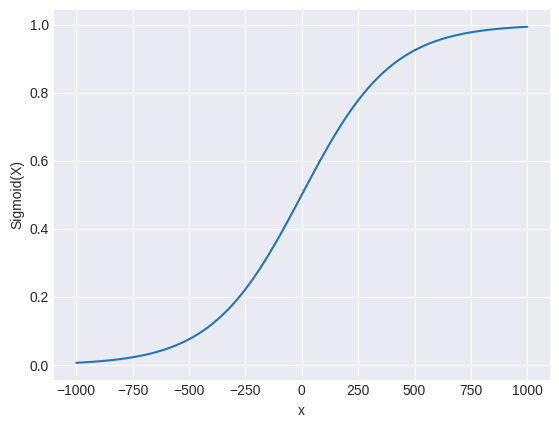

In [57]:

# Import matplotlib, numpy and math
import matplotlib.pyplot as plt
import numpy as np
import math
  
x = np.linspace(-1000, 1000, 100)
z = 1/(1 + np.exp(-0.005*x))
  
plt.plot(x, z)
plt.xlabel("x")
plt.ylabel("Sigmoid(X)")
  
plt.show()

In [58]:
def sigmoid(x):
  return 1/(1 + np.exp(-0.005*x))

In [59]:
def trading_day(t, table, curr_cash, curr_assets, bitcoin_comission, gold_comission):
  bitcoin_comission = 0.01
  gold_comission = 0.02

  # HYPERPARAMETERS
  gold_period = 50 #moving average

  gold_margin = 50
  gold_comission = 0.01

  bitcoin_period = 50
  bitcoin_margin = 100
  bitcoin_comission = 0.02

  gradient_period = 5

  bitcoin_buy_amount_multi = 0.2
  gold_buy_amount_multi = 0.05
  bitcoin_sell_amount_multi = 10
  gold_sell_amount_multi = 0.2

  row = table.loc[t, :]
  # Dont do any purchases until we have enough data
  if t < 6:
    table.loc[t, 'bitcoin-value-at-hand'] = 0
    table.loc[t, 'gold-value-at-hand'] = 0
    table.loc[t, 'cash-at-hand'] = curr_cash
    return curr_cash, curr_assets

  # get current prices
  gold_price = table['gold-price'][t]
  bitcoin_price = table['bitcoin-price'][t]

  # Get gradient over 5 days
  gold_gradient = table['gold-price'][t] - table['gold-price'][t-gradient_period]
  table.loc[t, 'gold-gradient']= gold_gradient

  bitcoin_gradient = table['bitcoin-price'][t] - table['bitcoin-price'][t-gradient_period]
  table.loc[t, 'bitcoin-gradient'] = bitcoin_gradient

  if t>50:
    # getting bitcoin and gold gradient over last 50 days
    gold_50_gradient = table['gold-price'][t] - table['gold-price'][t-50]
    table.loc[t, 'gold-50-gradient']= gold_50_gradient

    bitcoin_50_gradient = table['bitcoin-price'][t] - table['bitcoin-price'][t-50]
    table.loc[t, 'bitcoin-50-gradient'] = bitcoin_50_gradient

    gold_period = int(round(gold_period/gold_50_gradient,0))
    bitcoin_period = int(round(bitcoin_period/bitcoin_50_gradient,0))

  # Dont do any purchases until we have enough data
  if t < gold_period or t < bitcoin_period:
    table.loc[t, 'bitcoin-value-at-hand'] = 0
    table.loc[t, 'gold-value-at-hand'] = 0
    table.loc[t, 'cash-at-hand'] = curr_cash
    return curr_cash, curr_assets

  # calculate moving average over past period days
  gold_sma = table['gold-price'][t-gold_period:t].mean()
  table.loc[t, 'gold-sma']= gold_sma

  bitcoin_sma = table['bitcoin-price'][t-bitcoin_period:t].mean()  
  table.loc[t, 'bitcoin-sma']= bitcoin_sma
  
  # getting buy and sell indicators
  buy_gold_indicator = buy_indicator(gold_price, gold_sma, gold_gradient)
  table.loc[t, 'buy_gold_indicator'] = buy_gold_indicator
  buy_bitcoin_indicator = buy_indicator(bitcoin_price, bitcoin_sma, bitcoin_gradient)
  table.loc[t, 'buy_bitcoin_indicator'] = buy_bitcoin_indicator

  sell_gold_indicator = sell_indicator(gold_price, gold_sma, gold_comission, gold_margin)
  table.loc[t, 'sell_gold_indicator'] = sell_gold_indicator
  sell_bitcoin_indicator = sell_indicator(bitcoin_price, bitcoin_sma, bitcoin_comission, bitcoin_margin)
  table.loc[t, 'sell_bitcoin_indicator'] = sell_bitcoin_indicator

  
  
  # determine what to buy
  if buy_bitcoin_indicator > 0 or buy_gold_indicator > 0:
    if buy_bitcoin_indicator > buy_gold_indicator:
      # to get buy percentage, divide buy bitcoin indicator (same as gradient) by maximum observed gradient and then by 5
      buy_percentage = bitcoin_buy_amount_multi*sigmoid(buy_bitcoin_indicator)
      #print(buy_percentage)
      buy_value = curr_cash*buy_percentage
      curr_cash, curr_assets = buy(asset='bitcoin',
                                  curr_price=bitcoin_price,
                                  buy_value=buy_value,
                                  cash=curr_cash,
                                  assets=curr_assets,
                                  comission=bitcoin_comission)
    else:
      # to get buy percentage, divide buy bitcoin indicator (same as gradient) by maximum observed gradient and then by 5
      buy_percentage = gold_buy_amount_multi*sigmoid(buy_gold_indicator)
      #print(buy_percentage)
      buy_value = curr_cash*buy_percentage
      curr_cash, curr_assets = buy(asset='gold',
                                  curr_price=gold_price,
                                  buy_value=buy_value,
                                  cash=curr_cash,
                                  assets=curr_assets,
                                  comission=gold_comission)

  if sell_bitcoin_indicator > 0:
    # sell percentage is profit per unit divided by price per unit multiply
    # profit per unit is buying indicator + margin
    sell_percentage = bitcoin_sell_amount_multi*(sell_bitcoin_indicator + bitcoin_margin)/(bitcoin_price)
    sell_amount = curr_assets['bitcoin']*sell_percentage
    curr_cash, curr_assets = sell(asset='bitcoin',
                                  curr_price=bitcoin_price,
                                  sell_amount=sell_amount,
                                  cash=curr_cash,
                                  assets=curr_assets,
                                  comission=bitcoin_comission)
  if sell_gold_indicator > 0:
    # sell percentage is profit per unit divided by price per unit multiply by 5
    # profit per unit is buying indicator + margin
    sell_percentage = gold_sell_amount_multi*(sell_gold_indicator + gold_margin)/gold_price
    sell_amount = curr_assets['gold']*sell_percentage
    curr_cash, curr_assets = sell(asset='gold',
                                  curr_price=gold_price,
                                  sell_amount=sell_amount,
                                  cash=curr_cash,
                                  assets=curr_assets,
                                  comission=gold_comission)
    
  table.loc[t, 'bitcoin-value-at-hand'] = curr_assets['bitcoin']*bitcoin_price
  table.loc[t, 'gold-value-at-hand'] = curr_assets['gold']*gold_price
  table.loc[t, 'cash-at-hand'] = curr_cash

  return curr_cash, curr_assets

In [60]:
def simulate(table):
  bitcoin_comission = 0.02
  gold_comission = 0.01
  
  cash = 10000
  assets = {'bitcoin':0, 'gold':0}

  for t in range(len(table)):
    cash,assets = trading_day(t, table, cash, assets, bitcoin_comission, gold_comission)
    if t % 100 == 0:
      #print(f"bitcoin_amount:{assets['bitcoin']}")
      #print(f"bitcoin_price:{table['bitcoin-price'][t]}")
      print(f"day {t} cash: {table['cash-at-hand'][t]}, gold-value: {table['gold-value-at-hand'][t]}, bitcoin-value: {table['bitcoin-value-at-hand'][t]}")
      
       
      
  #sell anything remaining in the end - not needed anymore
  """
  cash, assets = sell(asset='bitcoin', curr_price=table.iloc[-1]['bitcoin-price'],
                                       sell_amount=assets['bitcoin'],
                                       cash=cash,
                                       assets=assets,
                                       comission=bitcoin_comission)
  
  cash, assets = sell(asset='gold', curr_price=table.iloc[-1]['gold-price'],
                                       sell_amount=assets['gold'],
                                       cash=cash,
                                       assets=assets,
                                       comission=bitcoin_comission)
  """

  final_value = table['cash-at-hand'][len(table)-1]+table['gold-value-at-hand'][len(table)-1]+table['bitcoin-value-at-hand'][len(table)-1]
  print(f"Final value at hand: {round(final_value,2)} which gives {round(final_value/100,2)} % ROI")

In [61]:
simulate(result)

day 0 cash: 10000.0, gold-value: 0.0, bitcoin-value: 0.0
day 100 cash: 7032.595620067734, gold-value: 219.85498067222713, bitcoin-value: 3028.8706985804656
day 200 cash: 3532.038133613208, gold-value: 1329.494013220042, bitcoin-value: 6320.144024221214
day 300 cash: 1909.311750922311, gold-value: 1847.8434832106689, bitcoin-value: 17568.07605747238
day 400 cash: 8445.319428830971, gold-value: 3271.8004463670927, bitcoin-value: 22907.436824526594
day 500 cash: 7819.799047641777, gold-value: 4041.978443808452, bitcoin-value: 45252.723496766914
day 600 cash: 5684.890903391672, gold-value: 5011.344069159023, bitcoin-value: 40146.89949316646
day 700 cash: 20411.830354440965, gold-value: 4723.963489789067, bitcoin-value: 14218.544188140473
day 800 cash: 15494.017132082472, gold-value: 7606.368631777281, bitcoin-value: 12006.971273882667
day 900 cash: 10506.426552076939, gold-value: 11144.330887368604, bitcoin-value: 11859.238008104829
day 1000 cash: 9978.519753619541, gold-value: 11753.47331

<ipython-input-62-01f57f7c69fe>:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-darkgrid')


<Axes: >

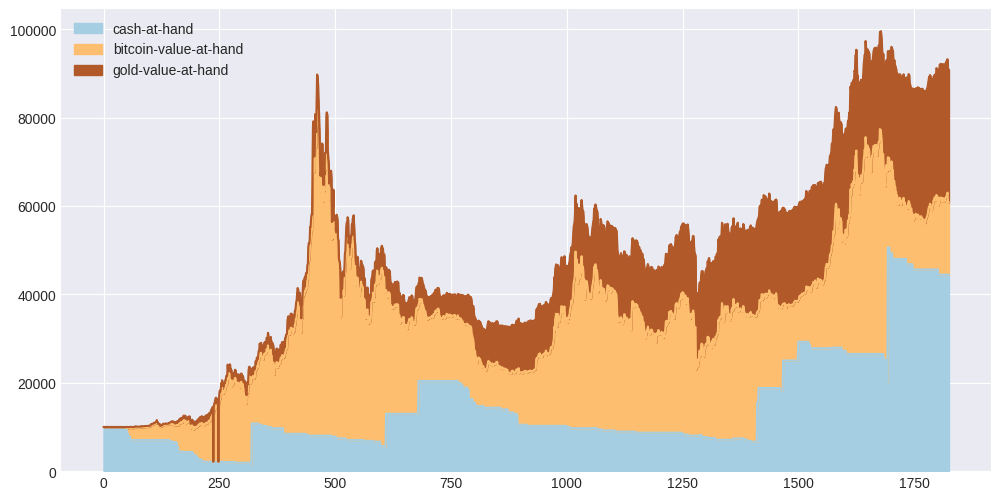

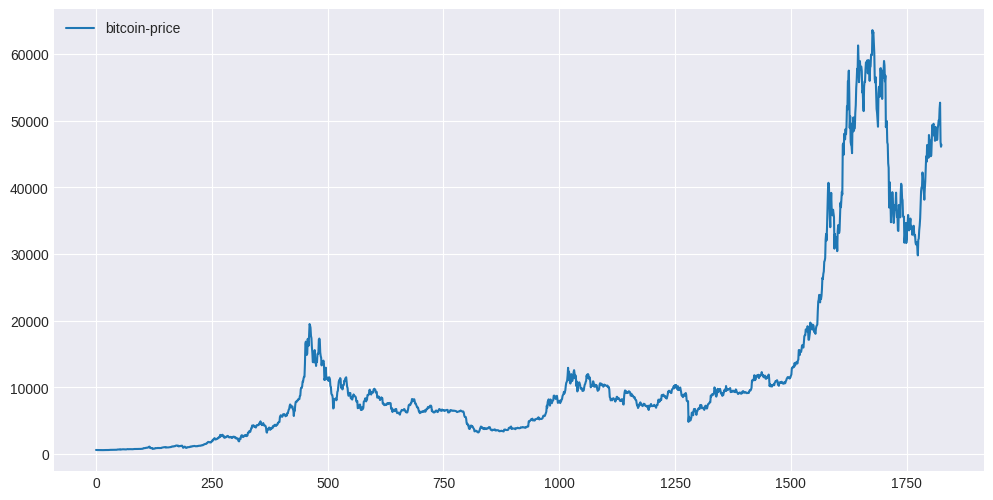

In [62]:
stackplot_data = result[['cash-at-hand', 'bitcoin-value-at-hand', 'gold-value-at-hand']]
stackplot_data.plot.area(figsize=(12, 6), colormap='Paired')
plt.figure(figsize=(12,6))
plt.style.use('seaborn-darkgrid')
sns.lineplot(data=result[['bitcoin-price']])

<Axes: >

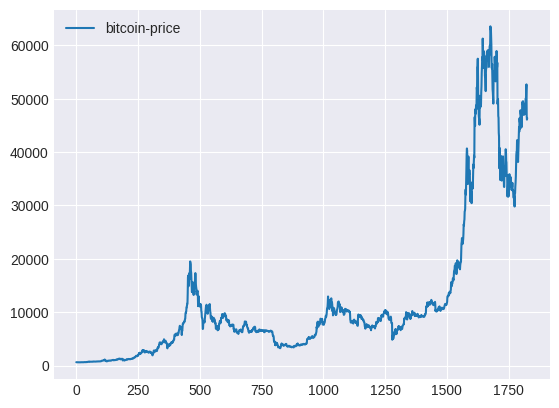

In [63]:
# bitcoin price and buy days chart

#buy_bitcoin_days = list(result.loc[result['buy_bitcoin_indicator']>0]['t'])
#for day in buy_bitcoin_days:
  #plt.axvline(day,color='g')
sns.lineplot(data=result[['bitcoin-price']])

In [64]:
result['buy_amount']= 0.2*result[['buy_bitcoin_indicator']].apply(sigmoid)

<ipython-input-65-4110757f653c>:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-darkgrid')


<Axes: >

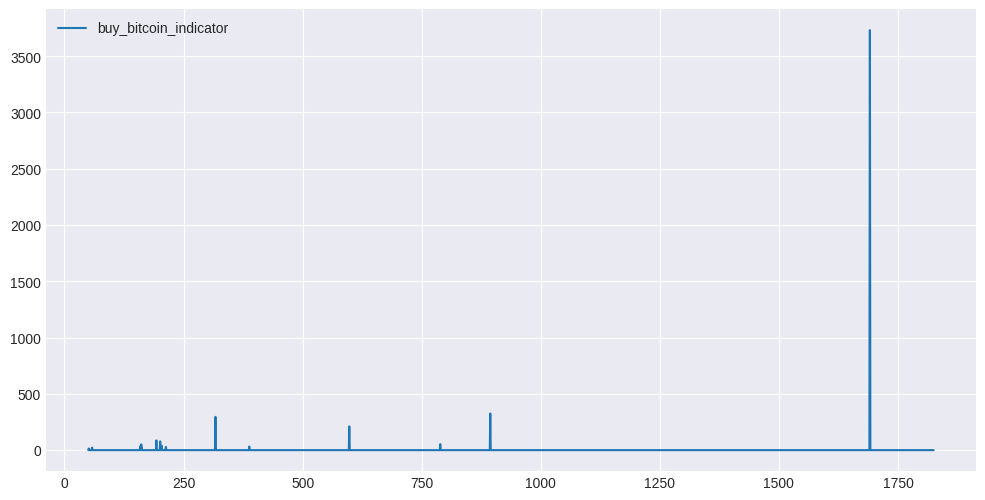

In [65]:
# bitcoin price and buy days chart
plt.figure(figsize=(12,6))
plt.style.use('seaborn-darkgrid')
#buy_bitcoin_days = list(result.loc[result['buy_bitcoin_indicator']>0]['t'])
#for day in buy_bitcoin_days:
  #plt.axvline(day,color='g')
sns.lineplot(data=result[['buy_bitcoin_indicator']])

<ipython-input-66-ffeb4216f043>:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-darkgrid')


<Axes: >

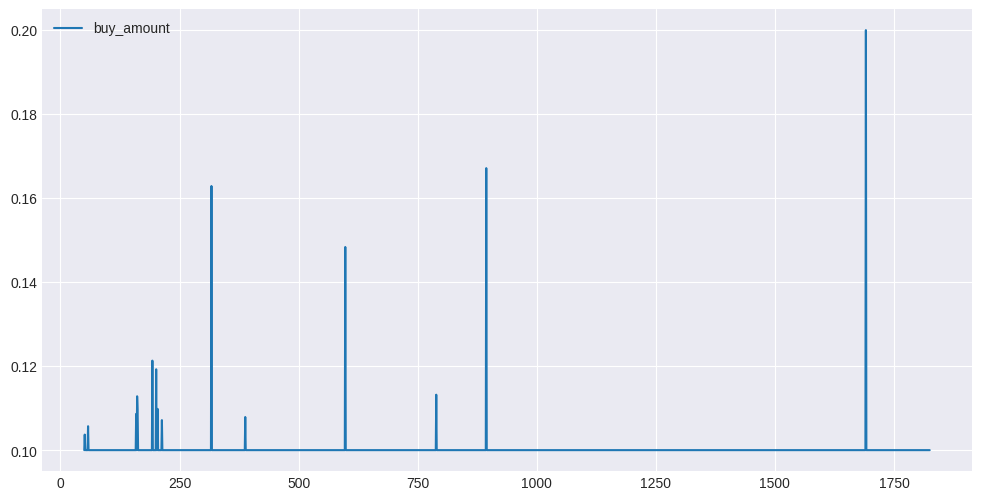

In [66]:
plt.figure(figsize=(12,6))
plt.style.use('seaborn-darkgrid')
sns.lineplot(data=result[['buy_amount']])

<Axes: >

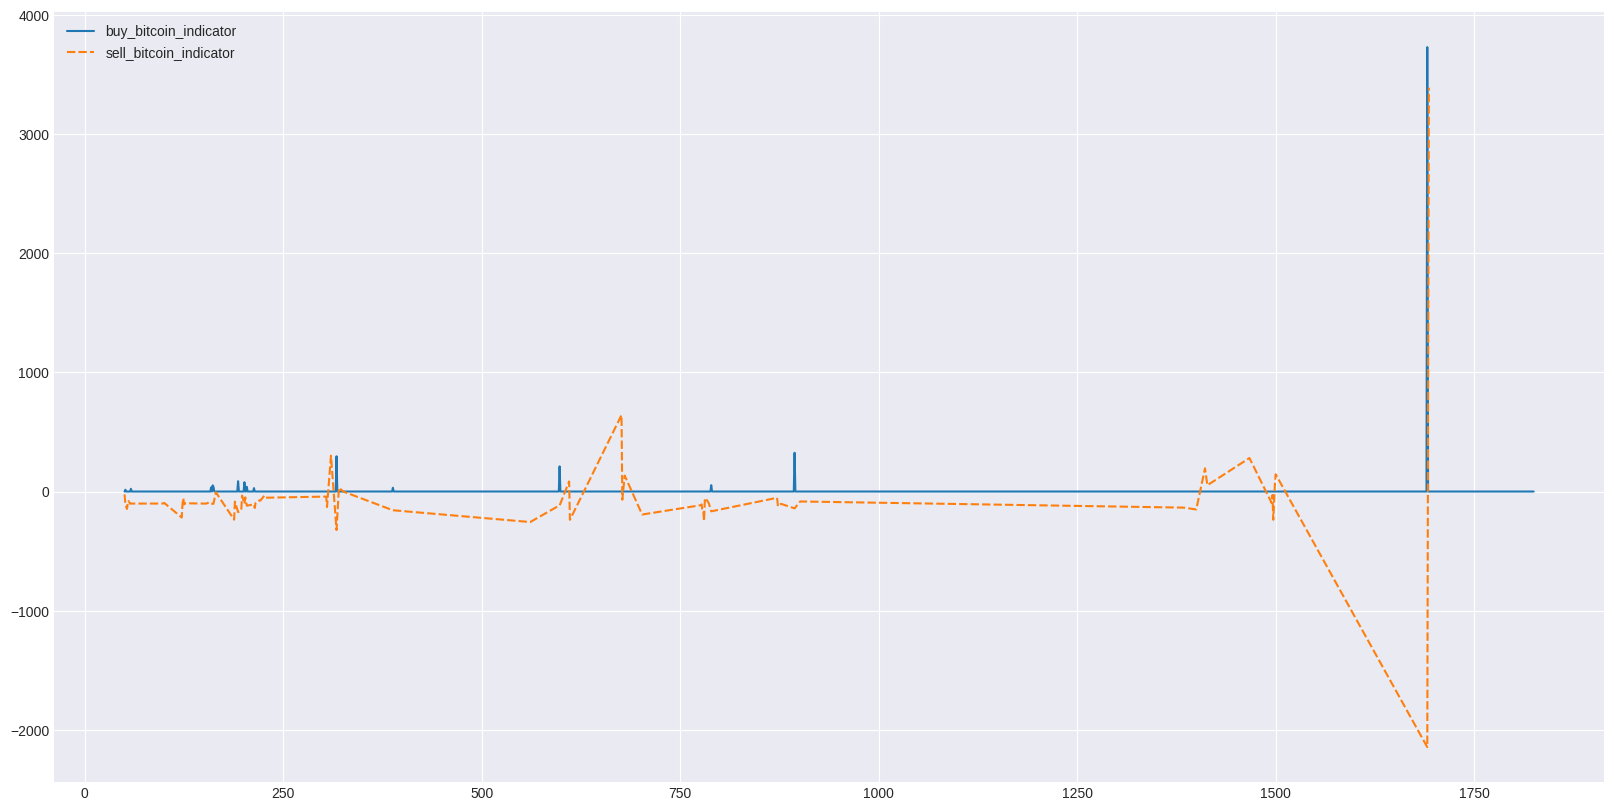

In [67]:
plt.figure(figsize=(20,10))
#buy_bitcoin_days = list(result.loc[result['buy_bitcoin_indicator']>0]['t'])
#for day in buy_bitcoin_days:
  #plt.axvline(day,color='g')
sns.lineplot(data=result[['buy_bitcoin_indicator', 'sell_bitcoin_indicator']])

<Axes: >

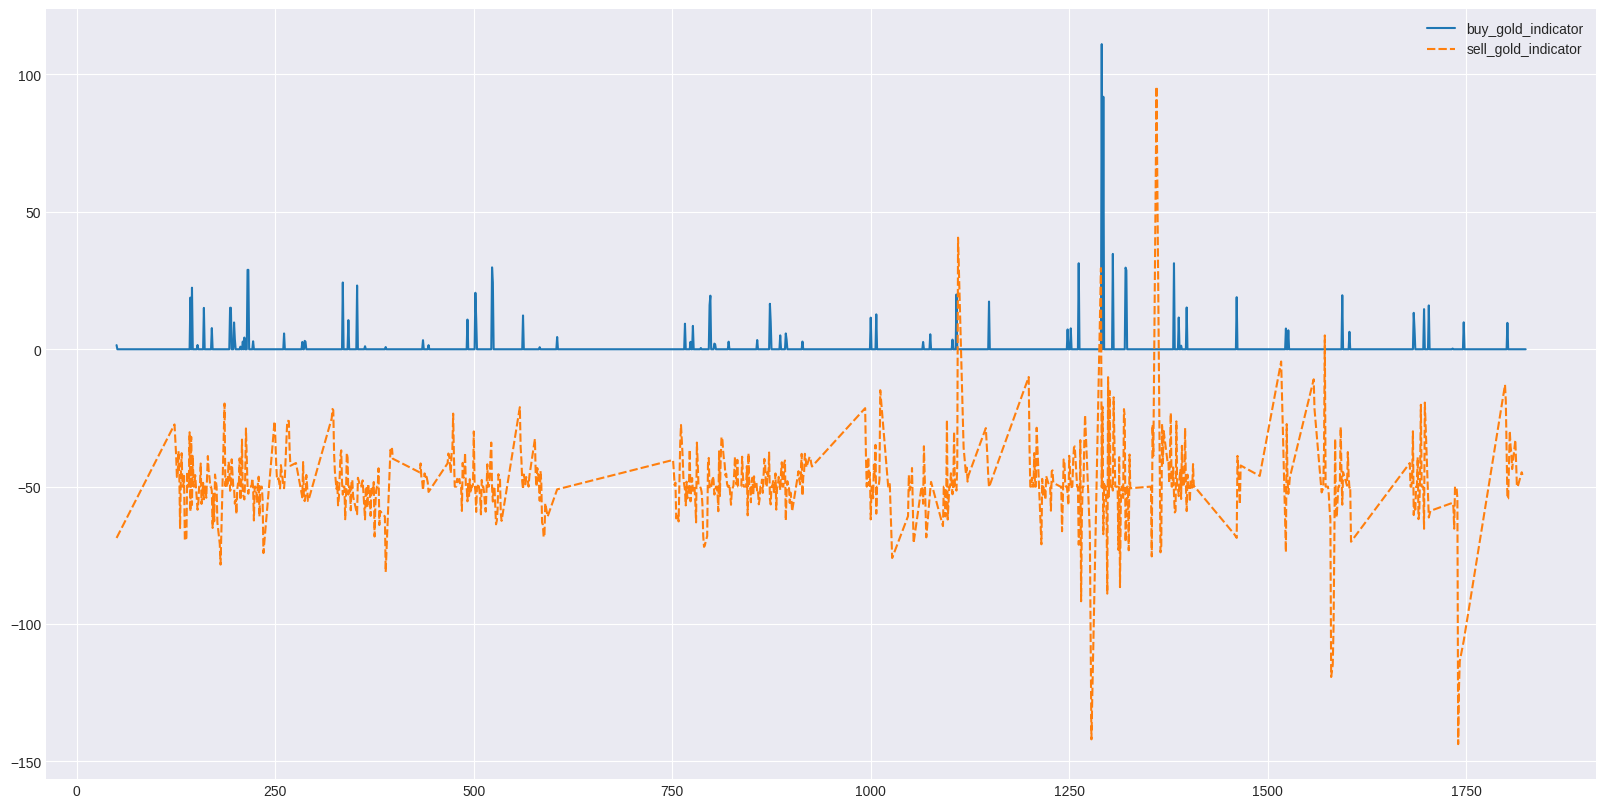

In [68]:
plt.figure(figsize=(20,10))
#buy_bitcoin_days = list(result.loc[result['buy_bitcoin_indicator']>0]['t'])
#for day in buy_bitcoin_days:
  #plt.axvline(day,color='g')
sns.lineplot(data=result[['buy_gold_indicator', 'sell_gold_indicator']])

<Axes: >

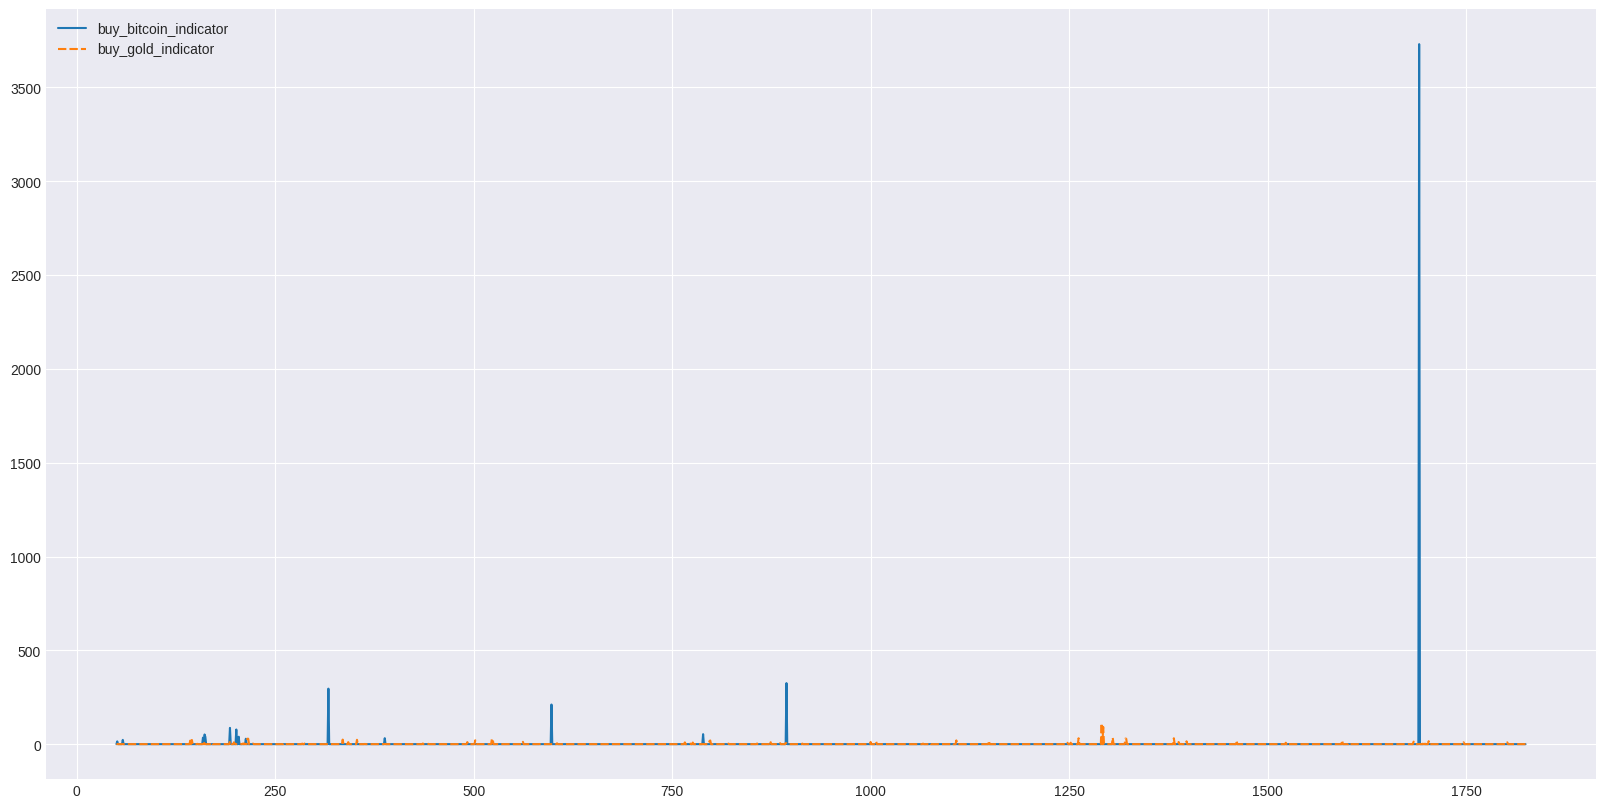

In [69]:
plt.figure(figsize=(20,10))
#buy_bitcoin_days = list(result.loc[result['buy_bitcoin_indicator']>0]['t'])
#for day in buy_bitcoin_days:
  #plt.axvline(day,color='g')
sns.lineplot(data=result[['buy_bitcoin_indicator', 'buy_gold_indicator']])

In [70]:
buy_gold_days = list(result.loc[result['buy_bitcoin_indicator']>0]['t'])
buy_bitcoin_days = list(result.loc[result['buy_gold_indicator']>0]['t'])

In [71]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
print("Setup Complete")

Setup Complete


<Axes: title={'center': 'Gold and bitcoin prices with suggested buy dates'}>

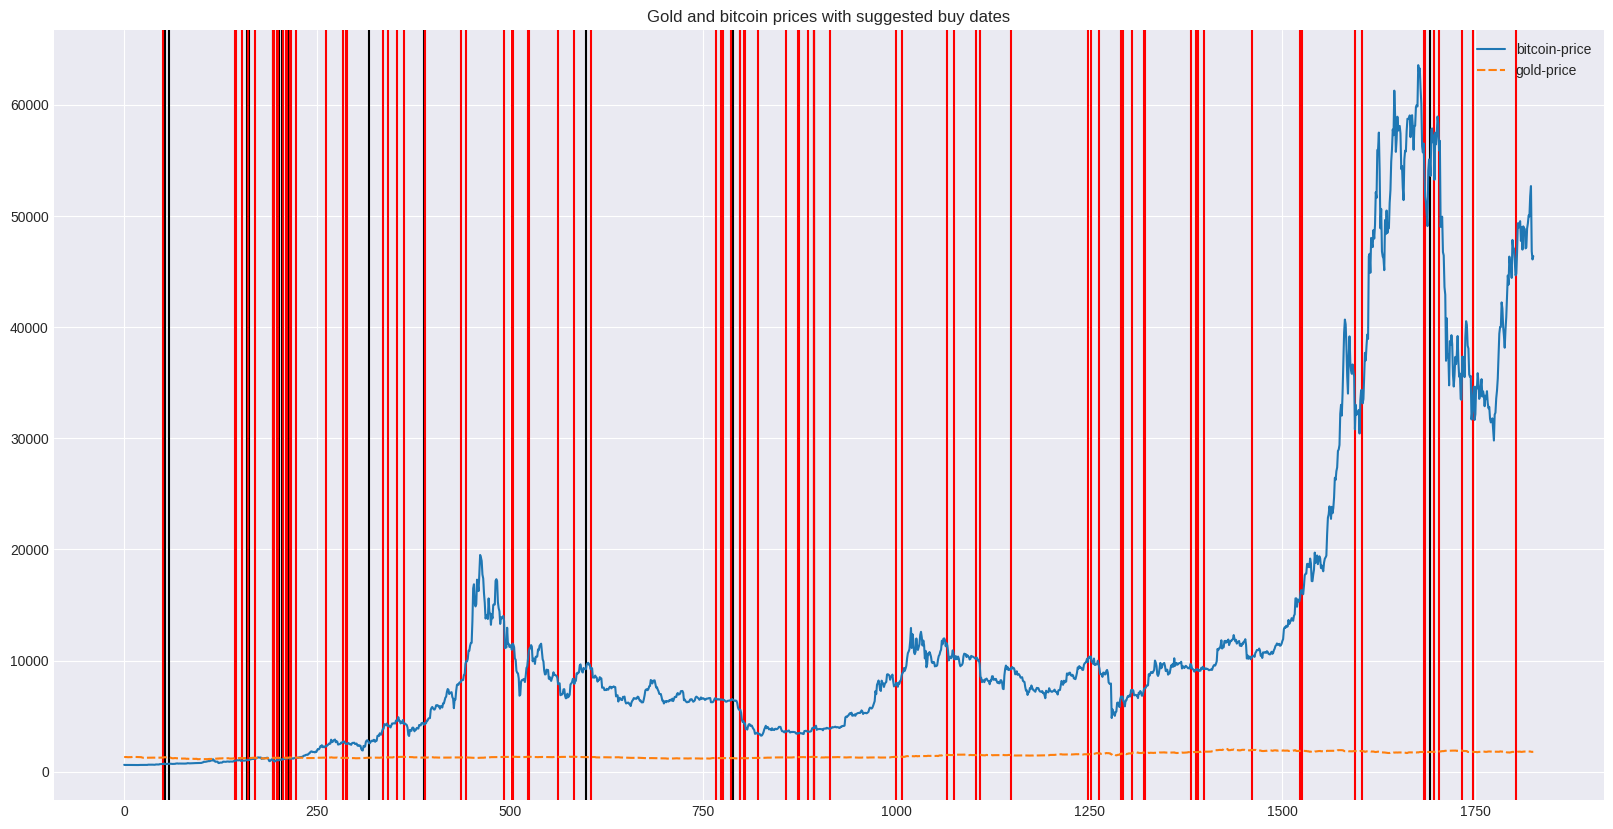

In [72]:
plt.figure(figsize=(20,10))
plt.title(f"Gold and bitcoin prices with suggested buy dates")
for day in buy_gold_days:
  plt.axvline(day,color='black')
for day in buy_bitcoin_days:
  plt.axvline(day,color='r')
sns.lineplot(data=result[['bitcoin-price', 'gold-price']])

# OLD

In [73]:
def buy_bitcoin(curr_price, curr_day, buy_value, assets, cash, transactions, buy_comission):
  if buy_value <= cash:
    cash = cash - buy_value
    buy_amount = buy_value/curr_price
    assets['bitcoin'] += (1-buy_comission)*buy_amount

    transaction = {'type':'buy', 
                  'day':curr_day,
                  'transation-price':curr_price,
                  'transaction-value':buy_value,
                  'asset-amoount':buy_amount}
    transactions.append(transaction)
    #print(f"bought {buy_amount} of bitcoin at {curr_price} for a total value of {buy_value}")
  else:
    pass
    #print("not enough cash")
  return cash, assets

In [74]:
def sell_bitcoin(curr_price, curr_day, sell_amount, assets, cash, transactions, sell_comission):
  if sell_amount <= assets['bitcoin']:
    sell_value =  sell_amount*curr_price
    cash += (1-sell_comission)*sell_value
    assets['bitcoin'] = assets['bitcoin'] -  sell_amount

    transaction = {'type':'sell', 
                  'day':curr_day,
                  'transation-price':curr_price,
                  'transaction-value':sell_value,
                  'asset-amoount':sell_amount}
    transactions.append(transaction)
    #print(f"sold {sell_amount} of bitcoin at {curr_price} for a total value of {sell_value}")
  else:
    pass
    #print('not enough bitcoin')
  return cash, assets

In [75]:
def buy_bitcoin(curr_price, curr_day, value_to_buy, assets, cash):
  asset = {'type':'bitcoin', 
          'purchase-day':curr_day,
          'purchase-price':curr_price,
          'purchase-value':value_to_buy,
          'asset-amount':value_to_buy/curr_price}
  cash -= value_to_buy
  assets.append(asset)
  print(f"bought {asset['asset-amount']} of bitcoin at {asset['purchase-price']} on day {asset['purchase-day']} for a total purchase value of {asset['purchase-value']}")

In [76]:
def sell_bitcoin(curr_price, asset, cash, assets, sell_comission):
  sell_profit_before_comission = (curr_price - asset['purchase_price'])*asset['asset-amount']
  sell_profit = (1-sell_comission)*sell_profit_before_comission
  cash += sell_profit
  assets.remove(asset)
  print(f"sold {asset['asset-amount']} of bitcoin at {curr_price} purchased initially at {asset['purchase-price']} for a total profit after comission of {sell_profit}")

In [77]:
"""
for each day
if profit indicator is positive
invest 5% of available cash
if sell indicator is positive
we check if there is any asset we held longer than hold period
then we sell it
then we add amount sold to cash
"""

'\nfor each day\nif profit indicator is positive\ninvest 5% of available cash\nif sell indicator is positive\nwe check if there is any asset we held longer than hold period\nthen we sell it\nthen we add amount sold to cash\n'

In [78]:
def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.

    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

In [79]:
cash, assets = buy_bitcoin(10, 0, 100, assets, cash, transactions)
print(cash)
print(assets)
print(transactions)

NameError: ignored

In [ ]:
cash, assets = sell_bitcoin(20, 1, 10, assets, cash, transactions)
print(cash)
print(assets)
print(transactions)

In [ ]:
assets